# Trabajo en clase — Q-Learning con FrozenLake

En CheeseWorld construimos el algoritmo desde cero. Ahora utilizaremos el mismo procedimiento en un ambiente estándar de **Gymnasium**.

## Objetivo

Durante la clase debes relacionar cada parte del código con los conceptos:

- estado \(s\);
- acción \(a\);
- recompensa \(r\);
- Q-table;
- exploración y explotación;
- TD target;
- TD error;
- política greedy.

Este notebook tiene **espacios para discutir y escribir conclusiones durante la clase**.


## 1. Imports y funciones de Q-Learning


In [ ]:
import numpy as np
import gymnasium as gym
import random
import matplotlib.pyplot as plt
import time
from IPython.display import clear_output, display

from IPython.display import HTML
from matplotlib import animation
import matplotlib.pyplot as plt


def play_episode(env, Q=None, random_policy=False, max_steps=100, seed=None):
    """Ejecuta un episodio y devuelve sus frames y recompensa total."""
    state, _ = env.reset(seed=seed)
    frames = [env.render()]
    total_reward = 0.0

    for _ in range(max_steps):
        if random_policy:
            action = env.action_space.sample()
        else:
            q_values = Q[state]
            max_q = np.max(q_values)

            # Desempate aleatorio entre acciones con el mismo Q.
            best_actions = np.flatnonzero(q_values == max_q)
            action = int(np.random.choice(best_actions))

        next_state, reward, terminated, truncated, _ = env.step(action)

        frames.append(env.render())
        total_reward += reward
        state = next_state

        if terminated or truncated:
            break

    return frames, total_reward


def frames_to_video(frames, interval=700):
    """Convierte una lista de frames RGB en una animación reproducible en Jupyter."""
    fig = plt.figure(figsize=(4, 4))
    plt.axis("off")

    image = plt.imshow(frames[0])

    def update(frame):
        image.set_data(frame)
        return [image]

    anim = animation.FuncAnimation(
        fig,
        update,
        frames=frames,
        interval=interval,
        blit=True,
        repeat=True
    )

    plt.close(fig)
    return HTML(anim.to_jshtml())


def initialize_q_table(state_space, action_space):
    return np.zeros((state_space, action_space))


def greedy_policy(Qtable, state):
    # Si hay empate entre varias acciones con el mismo Q, desempata al azar.
    max_q = np.max(Qtable[state])
    best_actions = np.flatnonzero(Qtable[state] == max_q)
    return int(np.random.choice(best_actions))


def epsilon_greedy_policy(Qtable, state, epsilon, env):
    if random.random() < epsilon:
        return env.action_space.sample()

    return greedy_policy(Qtable, state)


def train_q_learning(
    env,
    Qtable,
    n_episodes=5000,
    learning_rate=0.7,
    gamma=0.95,
    max_epsilon=1.0,
    min_epsilon=0.05,
    decay_rate=0.001,
    max_steps=100,
    start_episode=0,
):
    rewards = []

    for episode in range(n_episodes):
        state, _ = env.reset()
        total_reward = 0

        global_episode = start_episode + episode
        epsilon = min_epsilon + (
            max_epsilon - min_epsilon
        ) * np.exp(-decay_rate * global_episode)

        for _ in range(max_steps):
            action = epsilon_greedy_policy(
                Qtable, state, epsilon, env
            )

            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            best_next_q = 0.0 if done else np.max(Qtable[next_state])

            td_target = reward + gamma * best_next_q
            td_error = td_target - Qtable[state, action]

            Qtable[state, action] += learning_rate * td_error

            state = next_state
            total_reward += reward

            if done:
                break

        rewards.append(total_reward)

    return Qtable, rewards


def evaluate_q_policy(env, Qtable, n_episodes=100, max_steps=100):
    episode_rewards = []

    for _ in range(n_episodes):
        state, _ = env.reset()
        total_reward = 0

        for _ in range(max_steps):
            action = greedy_policy(Qtable, state)

            next_state, reward, terminated, truncated, _ = env.step(action)

            state = next_state
            total_reward += reward

            if terminated or truncated:
                break

        episode_rewards.append(total_reward)

    return np.mean(episode_rewards), np.std(episode_rewards)


def show_frame(env, title=''):
    frame = env.render()
    plt.figure(figsize=(4, 4))
    plt.imshow(frame)
    plt.axis('off')
    plt.title(title)
    display(plt.gcf())
    plt.close()

### 💬 Antes de ejecutar

En CheeseWorld teníamos explícitamente una clase `Environment` y una clase `QLearningAgent`.

**Pregunta:** en este notebook, ¿qué papel cumple Gymnasium y dónde quedó representado el agente?

**Notas:**

**Gymnasium** cumple el papel de la clase CheeseWorld del notebook anterior, definiendo en una clase un entorno en donde se establecen las posibles posiciones, rewards, el estado actual del agente en la propiedad "state", y las funciones de reseteo para ejecución episódica, así como la función de "step" para devolver la recompensa inmediata de dicho estado y el estado nuevo.

Las funciones para obtener el mejor Qvalue según la política epsilon-greedy y la actualización de la Q function ya no hacen parte de una clase como tal.


## 2. Crear FrozenLake


In [ ]:
env = gym.make(
    "FrozenLake-v1",
    map_name="4x4",
    is_slippery=False,
    render_mode="rgb_array"
)

state, info = env.reset()

print("Estado inicial:", state)
print("Número de estados:", env.observation_space.n)
print("Número de acciones:", env.action_space.n)

Estado inicial: 0
Número de estados: 16
Número de acciones: 4


En FrozenLake las acciones son:

| Acción | Código |
|---|---:|
| Left | 0 |
| Down | 1 |
| Right | 2 |
| Up | 3 |

Primero trabajaremos con `is_slippery=False`, es decir, con transiciones determinísticas.


### 💬 Actividad 1 — La Q-table

Antes de crearla:

1. ¿Cuántas filas debe tener la Q-table?
2. ¿Cuántas columnas?
3. ¿Qué representa una celda \(Q[s,a]\)?

**Respuesta / discusión:**

Q-Table debe tener N cantidad de filas y M cantidad de columnas, donde:

**N:** Cantidad de estados posibles

**M:** Total de acciones posibles para un estado t


Por ende, una celda Q[s, a] donde s es un estado $S_t$ y a es una acción $A_t$, representa el valor de la función de utilidad que se obtiene al estar en un estado s y realizar la acción a


In [ ]:
state_space = env.observation_space.n
action_space = env.action_space.n

Q = initialize_q_table(state_space, action_space)

print("Q-table shape:", Q.shape)
Q

Q-table shape: (16, 4)


array([[0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.]])

### 💬 Actividad 2 — Inicio del aprendizaje

Todos los valores son cero.

$$
Q(s,a)=0
$$

¿Esto significa que todas las acciones son malas, o que el agente todavía no sabe nada?

¿Qué ocurre si varias acciones tienen exactamente el mismo valor máximo?

**Notas:**

Cuando se inicializa la tabla Q en cero, las primeras ejecuciones de episodios son básicamente un random-walk, sin información por la cual tomar decisiones óptimas. Mientras los valores se vayan almacenando según la política, estas decisiones mejorarán. Es decir, que exista un entrenamiento.

Si varias acciones tienen el mismo valor máximo, se toma la decisión de desempate a partir de una elección aleatoria entre todas esas acciones.


## 3. Ejecutar una transición


In [ ]:
state, _ = env.reset()

epsilon = 1.0
action = epsilon_greedy_policy(Q, state, epsilon, env)

next_state, reward, terminated, truncated, _ = env.step(action)

print("state      =", state)
print("action     =", action)
print("reward     =", reward)
print("next_state =", next_state)
print("done       =", terminated or truncated)

state      = 0
action     = 0
reward     = 0
next_state = 0
done       = False


### 💬 Actividad 3 — Identificar la experiencia

Escribe la experiencia anterior como:

$$
(s,a,r,s')
$$

**Experiencia:**

$$
(0, 2, 0, 1)
$$

¿De cuál de esos cuatro elementos **no disponíamos directamente** en Value Iteration cuando hablábamos de experiencia real?

El valor de $s'$ es un elemento que no se disponía de antemano, debido a que la elección de este estado en el Value Iteration se basa en un ponderado de probabilidades; este problema de Q-learning se analiza asumiendo que las acciones son determinísticas.


## 4. Del azar a una política aprendida

Vamos a observar **el mismo agente en tres momentos**. Primero no sabe nada y actúa al azar; luego veremos su política después de pocas experiencias; finalmente veremos la política después del entrenamiento completo.


In [ ]:
# Guardaremos tres momentos del aprendizaje

# Momento 1: sin entrenamiento
Q_initial = initialize_q_table(
    env.observation_space.n,
    env.action_space.n
)

# Momento 2: poco entrenamiento
EARLY_EPISODES = 50
Q_early = Q_initial.copy()
Q_early, rewards_early = train_q_learning(
    env,
    Q_early,
    n_episodes=EARLY_EPISODES,
    learning_rate=0.7,
    gamma=0.95,
    max_epsilon=1.0,
    min_epsilon=0.05,
    decay_rate=0.001,
)

# Momento 3: continuar hasta 10 000 episodios
TOTAL_EPISODES = 10000
Q_trained = Q_early.copy()
Q_trained, rewards_final = train_q_learning(
    env,
    Q_trained,
    n_episodes=TOTAL_EPISODES - EARLY_EPISODES,
    learning_rate=0.7,
    gamma=0.95,
    max_epsilon=1.0,
    min_epsilon=0.05,
    decay_rate=0.001,
    start_episode=EARLY_EPISODES,
)

Q = Q_trained
rewards = rewards_early + rewards_final

print('Snapshots guardados:')
print('Q_initial : 0 episodios')
print(f'Q_early   : {EARLY_EPISODES} episodios')
print(f'Q_trained : {TOTAL_EPISODES} episodios')


Snapshots guardados:
Q_initial : 0 episodios
Q_early   : 50 episodios
Q_trained : 10000 episodios


### Momento 1 — Sin entrenamiento: random walk
Todavía no usamos la Q-table para decidir. Cada acción se selecciona aleatoriamente. Observa cómo interactúa el agente con el mundo.

In [ ]:
frames_random, reward_random = play_episode(
    env,
    Q_initial,
    random_policy=True,
    seed=7
)

print(f"Recompensa total: {reward_random}")
print(Q_initial)
frames_to_video(frames_random, interval=700)

Recompensa total: 0.0
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]


### Momento 2 — Después de pocas iteraciones

Ahora el agente usa de forma **greedy** lo que ha aprendido en `Q_early`. Todavía conoce poco del ambiente, así que su comportamiento puede ser incompleto o equivocarse.


In [ ]:
frames_early, reward_early = play_episode(
    env,
    Q_early,
    random_policy=False,
    seed=7
)

print(f"Recompensa total: {reward_early}")
print(Q_early)
frames_to_video(frames_early, interval=700)


Recompensa total: 0.0
[[0.         0.         0.         0.        ]
 [0.         0.         0.         0.        ]
 [0.         0.         0.         0.        ]
 [0.         0.         0.         0.        ]
 [0.         0.         0.         0.        ]
 [0.         0.         0.         0.        ]
 [0.         0.         0.         0.        ]
 [0.         0.         0.         0.        ]
 [0.         0.         0.         0.        ]
 [0.         0.3095575  0.         0.        ]
 [0.         0.         0.         0.        ]
 [0.         0.         0.         0.        ]
 [0.         0.         0.         0.        ]
 [0.         0.52315217 0.60515    0.        ]
 [0.40242475 0.         0.7        0.        ]
 [0.         0.         0.         0.        ]]


### Momento 3 — Agente entrenado

Finalmente usamos `Q_trained`. Ya no exploramos: en cada estado el agente selecciona una de las acciones con mayor valor $Q(s,a)$.


In [ ]:
frames_trained, reward_trained = play_episode(
    env,
    Q_trained,
    random_policy=False,
    seed=7
)

print(f"Recompensa total: {reward_trained}")
print(Q_trained)
frames_to_video(frames_trained, interval=700)


Recompensa total: 1.0
[[0.73509189 0.77378094 0.77378094 0.73509189]
 [0.73509189 0.         0.81450625 0.77378094]
 [0.77378094 0.857375   0.77378094 0.81450625]
 [0.81450625 0.         0.77378094 0.77378093]
 [0.77378094 0.81450625 0.         0.73509189]
 [0.         0.         0.         0.        ]
 [0.         0.9025     0.         0.81450625]
 [0.         0.         0.         0.        ]
 [0.81450625 0.         0.857375   0.77378094]
 [0.81450625 0.9025     0.9025     0.        ]
 [0.857375   0.95       0.         0.857375  ]
 [0.         0.         0.         0.        ]
 [0.         0.         0.         0.        ]
 [0.         0.9025     0.95       0.857375  ]
 [0.9025     0.95       1.         0.9025    ]
 [0.         0.         0.         0.        ]]


### 💬 Actividad — ¿Qué cambió?

Compara las tres ejecuciones. El ambiente, los estados y las acciones son los mismos. **¿Qué cambió internamente en el agente para que su comportamiento mejore?**

Observa `Q_initial`, `Q_early` y `Q_trained` y relaciona sus valores con las acciones que viste ejecutar.



Inicialmente, Q o **Q_initial** tiene 0 para todos los Q[s,a]:

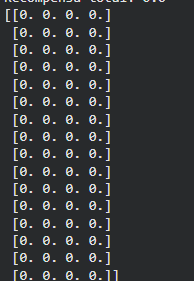

Por lo tanto, el comportamiento aleatorio tipo random-walk es totalmente esperado, ya que el agente no conoce nada sobre el ambiente.


Para **Q_early**, algunos pares de estado-accion ya tienen valores gracias al entrenamiento en una cantidad pequeña de episodios (50). Sin embargo, todavía comete errores debido a la poca información que posee, (cae en un estado terminal al elegir entre valores de 0, que son maximos parecidos entre si)

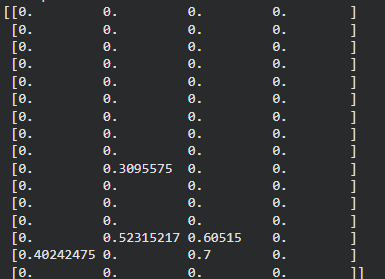


Finalmente, **Q_trained** ya tiene toda la tabla completamente llena de valores según las limitaciones del entorno (algunas pueden quedar en 0 al ser acciones no válidas dentro del entorno). Para los máximos identicos, se elige aleatoriamente entre estos y llega al mejor reward

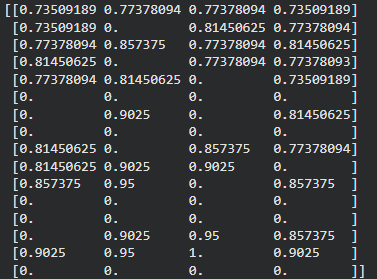

### 💬 Actividad 4 — Leer una fila de Q

Selecciona un estado $s$ y observa:

$$
Q(s,0), Q(s,1), Q(s,2), Q(s,3)
$$

**Estado seleccionado:** Estado $s_6$ (Empezando desde $s_0$)

**Valores Q:**

- Left: 0
- Down: 0.9025
- Right: 0
- Up: 0.81450625

¿Cuál acción seleccionaría:

$$
\arg\max_a Q(s,a)
$$

?

**Interpretación:**
La función de utilidad en el estado $s_6$ y acción $a_{down}$ es de 0.9025, el cual es el mayor valor de todas las acciones. Por ende, se elige como acción correspondiente a ese valor de 0.9025 para el estado $s_6$ la acción $a_1$, es decir, ***Down***
>


## 5. Evaluar la política aprendida


In [ ]:
mean_reward, std_reward = evaluate_q_policy(
    env,
    Q_trained,
    n_episodes=100
)

print(f"Mean reward: {mean_reward:.3f}")
print(f"Std reward : {std_reward:.3f}")


Mean reward: 1.000
Std reward : 0.000


### 💬 Actividad 5 — Exploration vs. exploitation

Durante entrenamiento usamos $\epsilon$-greedy.

Durante evaluación usamos:

$$
a=\arg\max_aQ(s,a)
$$

¿Por qué **no exploramos** durante la evaluación?

**Conclusión:**

No se explora ya que se quiere medir la optimalidad de la política encontrada ***hasta el momento de ejecución*** según la cantidad de episodios realizados. Para cada estado en el que el agente se mueva, se obtiene la acción que tiene asociada el mayor valor (argmax), obteniendo así la trayectoria hacia el camino de mejor recompensa encontrado.

>


## 6. Experimento: FrozenLake estocástico


In [ ]:
slippery_env = gym.make(
    "FrozenLake-v1",
    map_name="4x4",
    is_slippery=True,
    render_mode="rgb_array"
)

Q_slippery = initialize_q_table(
    slippery_env.observation_space.n,
    slippery_env.action_space.n
)

Q_slippery, rewards_slippery = train_q_learning(
    slippery_env,
    Q_slippery,
    n_episodes=20000,
    learning_rate=0.7,
    gamma=0.95,
    max_epsilon=1.0,
    min_epsilon=0.05,
    decay_rate=0.0005,
    max_steps=100
)

mean_reward, std_reward = evaluate_q_policy(
    slippery_env,
    Q_slippery,
    n_episodes=500
)

print(f"Mean reward: {mean_reward:.3f}")
print(f"Std reward : {std_reward:.3f}")

Mean reward: 0.722
Std reward : 0.448


### 💬 Actividad 6 — Determinístico vs. estocástico

Compara:

- `is_slippery=False`
- `is_slippery=True`

¿Qué cambia en el **ambiente**?

Ahora existe un componente que convierte el ambiente en uno estocástico, con probabilidad de "resbalarse". Según la definición de la librería, "is_slippery" para el entorno "FrozenLake" establece que existe una probabilidad de que el agente se mueva perpendicular a la acción intencionada.

¿Qué cambia en la **ecuación de Q-Learning**?

La ecuación de Q-Learning no cambia, debido a que es Model Free. En este caso específico, así exista un componente estocástico, Q-Learning siempre interactua con el entorno, y mientras se realizan los entrenamientos, los Q-values van cambiando según los experimentos realizados en cada episodio, funcionando como una media móvil de los valores posibles.

# Cierre de clase

Completa antes de terminar:

**1. ¿Qué almacena $Q(s,a)$?**

> Almacena el valor de la función de utilidad asociada al par de estado-accion.

**2. ¿De dónde sale $\max_{a'}Q(s',a')$?**

> Esto proviene de la política greedy, el cual busca obtener siempre la mejor acción del estado donde se encuentra, a partir de la maximización de la función de utilidad.

**3. ¿Por qué necesitamos $\epsilon$-greedy?**

> $\epsilon$-greedy define una función que, dependiendo del valor inicial de $\epsilon$, permite realizar una exploración inicial de las acciones posibles; explorar es necesario en *early* para que el agente pueda conocer distintas trayectorias e ir aprendiendo de las mismas. El valor de $\epsilon$ irá disminuyendo progresivamente mientras la tabla es llenada, priorizando la explotación en las etapas finales.

**4. ¿Por qué Q-Learning es model-free?**

> Es model-free por el método de aprendizaje, el cual es a través de prueba y error, lo cual lo hace independiente de conocer reglas, funciones de probabilidad para transición entre estados, etc. Las estimaciones se realizan a partir de la información que se conoce gracias a las acciones anteriores, concentrándose netamente en los valores.
